# Etapa 1. Visão geral e otimização dos dados

O foco dessa etapa é conhecer e entender como os dados estão organizados. Caso seja necessário, iremos alterar os tipos de dados das colunas para otimizá-los. Também iremos realizar a padronização dos nomes das colunas em casos que os nomes possuam letras maiúsculas ou espaços ao invés de sublinhados. 

Após essas alterações, nossos dados estarão adequados para seguirmos com a Etapa 2.

In [1]:
# Importando bibliotecas necessárias para o projeto
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

In [2]:
# Realizamos uma pré-análise em nossos dados para otimizá-los
pre_visits = pd.read_csv('/datasets/visits_log_us.csv', nrows=500)
pre_visits.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Device     500 non-null    object
 1   End Ts     500 non-null    object
 2   Source Id  500 non-null    int64 
 3   Start Ts   500 non-null    object
 4   Uid        500 non-null    uint64
dtypes: int64(1), object(3), uint64(1)
memory usage: 113.1 KB


Essa fatia dos dados da tabela visits nos mostra possíveis pontos de otimização. Iremos checar os valores da coluna Device, caso sejam valores que representem categorias, poderemos trocar seu tipo de dados para 'category'. As colunas 'End Ts' e 'Start Ts' possuem o tipo de dados 'object'. Iremos transformá-los para o tipo datetime.

Essas alterações irão otimizar nossos dados, tornando-os mais leves e agilizando o processo para analisá-los.

In [3]:
# Analisando a coluna 'device'
print(pre_visits['Device'].value_counts())

desktop    363
touch      137
Name: Device, dtype: int64


In [4]:
# Iremos transformar os dados da coluna 'device' para 'category'
pre_visits['Device'] = pre_visits['Device'].astype('category')

# Checamos se o tamanho do arquivo diminuiu
pre_visits.info(memory_usage='deep')

# Printamos o DataFrame 
print('-'*60)
print(pre_visits.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   Device     500 non-null    category
 1   End Ts     500 non-null    object  
 2   Source Id  500 non-null    int64   
 3   Start Ts   500 non-null    object  
 4   Uid        500 non-null    uint64  
dtypes: category(1), int64(1), object(2), uint64(1)
memory usage: 82.9 KB
------------------------------------------------------------
    Device               End Ts  Source Id             Start Ts  \
0    touch  2017-12-20 17:38:00          4  2017-12-20 17:20:00   
1  desktop  2018-02-19 17:21:00          2  2018-02-19 16:53:00   
2    touch  2017-07-01 01:54:00          5  2017-07-01 01:54:00   
3  desktop  2018-05-20 11:23:00          9  2018-05-20 10:59:00   
4  desktop  2017-12-27 14:06:00          3  2017-12-27 14:06:00   

                    Uid  
0  16879256277535980062  
1    10406035724489

In [5]:
# Convertemos os textos em datas para as colunas 'End Ts' e 'Start Ts'
pre_visits['End Ts'] = pd.to_datetime(pre_visits['End Ts'], format='%Y-%m-%d %H:%M:%')
pre_visits['Start Ts'] = pd.to_datetime(pre_visits['Start Ts'], format='%Y-%m-%d %H:%M:%')

# Checamos se o tamanho do arquivo diminuiu
pre_visits.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Device     500 non-null    category      
 1   End Ts     500 non-null    datetime64[ns]
 2   Source Id  500 non-null    int64         
 3   Start Ts   500 non-null    datetime64[ns]
 4   Uid        500 non-null    uint64        
dtypes: category(1), datetime64[ns](2), int64(1), uint64(1)
memory usage: 16.5 KB


Converter os dados dessas colunas possibilitou uma excelente otimização da nossa fatia da tabela. Agora, iremos carregar o arquivo inteiro otimizado, com os tipos de dados das colunas já alterados. Para isso, usaremos os parâmetros 'dtype' e 'parse_dates' no método pd.read_csv().

Iremos repetir todo esse processo para as outras duas tabelas. 

In [6]:
# Carregando a tabela visits
visits = pd.read_csv(
    '/datasets/visits_log_us.csv',
    dtype={'Device': 'category'},
    parse_dates=['Start Ts', 'End Ts']
)

# Trazendo suas informações
visits.info()
print('-'*60)
print(visits.head(5))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 359400 entries, 0 to 359399
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   Device     359400 non-null  category      
 1   End Ts     359400 non-null  datetime64[ns]
 2   Source Id  359400 non-null  int64         
 3   Start Ts   359400 non-null  datetime64[ns]
 4   Uid        359400 non-null  uint64        
dtypes: category(1), datetime64[ns](2), int64(1), uint64(1)
memory usage: 11.3 MB
------------------------------------------------------------
    Device              End Ts  Source Id            Start Ts  \
0    touch 2017-12-20 17:38:00          4 2017-12-20 17:20:00   
1  desktop 2018-02-19 17:21:00          2 2018-02-19 16:53:00   
2    touch 2017-07-01 01:54:00          5 2017-07-01 01:54:00   
3  desktop 2018-05-20 11:23:00          9 2018-05-20 10:59:00   
4  desktop 2017-12-27 14:06:00          3 2017-12-27 14:06:00   

                    

In [7]:
# Checando os tipos de dados da tabela orders
pre_orders = pd.read_csv('/datasets/orders_log_us.csv', nrows=500)

pre_orders.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Buy Ts   500 non-null    object 
 1   Revenue  500 non-null    float64
 2   Uid      500 non-null    uint64 
dtypes: float64(1), object(1), uint64(1)
memory usage: 45.0 KB


In [8]:
# Precisamos alterar apenas os dados da coluna 'Buy Ts' para datetime
orders = pd.read_csv(
    '/datasets/orders_log_us.csv',
    parse_dates=['Buy Ts']
)

# Informações de orders
orders.info()
print('-'*60)
print(orders.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50415 entries, 0 to 50414
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   Buy Ts   50415 non-null  datetime64[ns]
 1   Revenue  50415 non-null  float64       
 2   Uid      50415 non-null  uint64        
dtypes: datetime64[ns](1), float64(1), uint64(1)
memory usage: 1.2 MB
------------------------------------------------------------
               Buy Ts  Revenue                   Uid
0 2017-06-01 00:10:00    17.00  10329302124590727494
1 2017-06-01 00:25:00     0.55  11627257723692907447
2 2017-06-01 00:27:00     0.37  17903680561304213844
3 2017-06-01 00:29:00     0.55  16109239769442553005
4 2017-06-01 07:58:00     0.37  14200605875248379450


In [9]:
# Checando os tipos de dados da tabela costs
pre_costs = pd.read_csv('/datasets/costs_us.csv', nrows=500)

pre_costs.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   source_id  500 non-null    int64  
 1   dt         500 non-null    object 
 2   costs      500 non-null    float64
dtypes: float64(1), int64(1), object(1)
memory usage: 40.7 KB


In [10]:
# Precisamos alterar os dados da coluna dt para datetime
costs = pd.read_csv(
    '/datasets/costs_us.csv',
    parse_dates=['dt']
)

# Informações de costs
costs.info()
print('-'*60)
print(costs.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2542 entries, 0 to 2541
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   source_id  2542 non-null   int64         
 1   dt         2542 non-null   datetime64[ns]
 2   costs      2542 non-null   float64       
dtypes: datetime64[ns](1), float64(1), int64(1)
memory usage: 59.7 KB
------------------------------------------------------------
   source_id         dt  costs
0          1 2017-06-01  75.20
1          1 2017-06-02  62.25
2          1 2017-06-03  36.53
3          1 2017-06-04  55.00
4          1 2017-06-05  57.08


In [11]:
# Antes de continuarmos, iremos padronizar os nomes das colunas dos dataframes
# Para isso, criaremos uma função
def padronizar_colunas(df):
    """
    Modifica o DataFrame para padronizar os nomes das colunas:
    - Converte para letras minúsculas
    - Substitui espaços por sublinhados
    """
    df.columns = df.columns.str.lower().str.replace(' ', '_')
    return df

# Aplicamos nossa função aos DataFrames com colunas fora do padrão
df_lists = [visits, orders]

for df in df_lists:
    padronizar_colunas(df)

# Checamos se os nomes das colunas foram padronizados corretamente
print(visits.columns)
print(orders.columns)

Index(['device', 'end_ts', 'source_id', 'start_ts', 'uid'], dtype='object')
Index(['buy_ts', 'revenue', 'uid'], dtype='object')


# Etapa 2. Análises de negócio

Com todos os nossos dados carregados, formatados e otimizados, podemos prosseguir para a etapa seguinte. Nossas análises serão divididas e estruturadas em três grupos principais:
- Produto
- Vendas
- Marketing

Dessa forma, seremos capazes de extrair insights e tirar conclusões de forma estruturada e organizada. Feitas as análises, iremos compilar as principais conclusões e recomendar ações estratégicas aos especialistas de marketing.

## Etapa 2.1. Produtos

### Quantas pessoas usam-no a cada dia, semana e mês?

Para responder a essa pergunta, precisaremos encontrar a atividade diária, semanal e a mensal dos usuários. É importante ressaltar que precisamos encontrar os usuários únicos e não a quantidade total de usuários para cada período. 

In [12]:
# Para calcular as atividades diária, semanal e mensal, precisamos criar colunas separadas para os valores de ano, mês e semana
visits['session_year'] = visits['start_ts'].dt.year
visits['session_month'] = visits['start_ts'].dt.month
visits['session_week'] = visits['start_ts'].dt.week
visits['session_date'] = visits['start_ts'].dt.date

# Atividade diária
dau_total = visits.groupby('session_date').agg({'uid': 'nunique'}).mean()

# Atividade semanal
wau_total = visits.groupby(['session_year', 'session_week']).agg({'uid': 'nunique'}).mean()

# Atividade mensal
mau_total = visits.groupby(['session_year', 'session_month']).agg({'uid': 'nunique'}).mean()

print(f'Atividade diária dos usuários: {int(dau_total)}')
print(f'Atividade semanal dos usuários: {int(wau_total)}')
print(f'Atividade mensal dos usuários: {int(mau_total)}')

Atividade diária dos usuários: 907
Atividade semanal dos usuários: 5716
Atividade mensal dos usuários: 23228


### Quantas sessões ocorrem por dia?

Aqui, nós iremos calcular quantas **sessões** ocorem por dia, ou seja, não iremos contar apenas os usuários únicos, mas sim todos que entram por dia. 

In [13]:
# Agrupamos a tabela visits pela data da sessão do dia e contamos quantos usuários entraram
sessions_per_day = visits.groupby('session_date').agg({'uid': 'count'}).mean()

print(f'Sessões por dia: {int(sessions_per_day)}')

Sessões por dia: 987


O número de sessões diárias e o número de usuários únicos entrando por dia é muito próximo. Este é o primeiro indicativo do comportamento do usuário da Y.Afisha: os usuários não costumam entrar mais de uma vês por dia na plataforma.

### Qual é o comprimento de cada sessão?

Para conhecermos bem o perfil e o comportamento do usuário, precisamos entender quanto tempo ele fica online na plataforma. Para isso, iremos calcular a ASL (duração média da sessão) do usuário.

<AxesSubplot:>

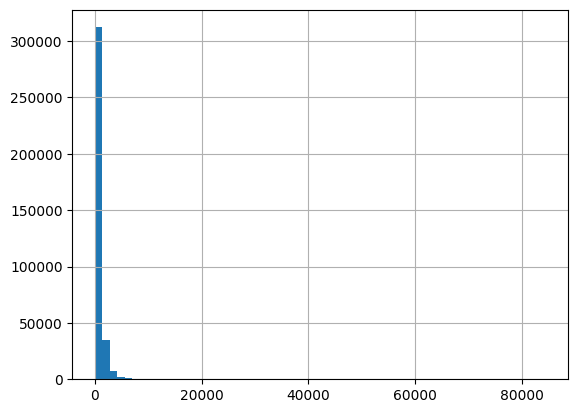

In [14]:
# Criamos uma coluna em nossa tabela visits para conter a duração da sessão em segundos
visits['session_duration_sec'] = (visits['end_ts'] - visits['start_ts']).dt.seconds

# Antes de calcularmos a ASL, iremos visualizar a distribuição dos dados com um histograma
visits['session_duration_sec'].hist(bins=60)

O histograma nos mostra uma distribuição disforme para a duração da sessão dos usuários. Para calcular a ASL corretamente, devemos usar a moda da distribuição do histograma, assim teremos um valor mais próximo da média real que os usuários passam na plataforma.

In [15]:
# Usamos a moda para calcular a ASL
asl = visits['session_duration_sec'].mode()

print(f'Duração da sessão média: {int(asl[0])} segundos')

Duração da sessão média: 60 segundos


Outra informação importante para definir o padrão de comportamento do nosso usuário médio: o tempo que ele passa, em média, na plataforma, é de 60 segundos. Ele entra para realizar ações pontuais e decididas, após isso, sai da plataforma e não volta mais no dia.

### Com que frequência os usuários voltam?

Para responder a essa pergunta, iremos calcular as taxas de retenção semanal e mensal em porcentagem. O nosso resultado nos mostrará a fidelidade dos nossos clientes. 

Nossas taxas de retenção serão calculadas utilizando os valores que encontramos para usuários únicos.

In [16]:
# Com que frequência os usuários voltam?

# Taxa de retenção semanal em %
# Dividimos a atividade diária pela atividade semanal
sticky_wau = dau_total / wau_total * 100 

# Taxa de retenção mensal em %
# Dividimos a atividade diária pela atividade mensal
sticky_mau = dau_total / mau_total * 100

print(f"Taxa de retenção semanal: {round(sticky_wau['uid'], 2)}%")
print(f"Taxa de retenção mensal: {round(sticky_mau['uid'], 2)}%")

Taxa de retenção semanal: 15.88%
Taxa de retenção mensal: 3.91%


De acordo com as respostas que obtivemos, podemos concluir que o usuário médio não costuma voltar para a plataforma depois do primeiro acesso, além disso, a duração média de sua sessão é de apenas 60 segundos.

As taxas de retenção semanal e mensal reforçam a afirmação de que o usuário não costuma voltar na mesma semana, nem no mesmo mês. Vamos entender melhor o que a porcentagem de nossas taxas representam. Para isso, vamos imaginar uma situação hipotética em que a atividade diária de **usuários únicos** na plataforma seja 1 e que ao longo da semana, apenas um usuário único entre na plataforma por dia.

Dessa forma, teríamos 1 usuário único por dia (dau) e 7 usuários únicos por semana (wau). A taxa de retenção semanal nesse caso seria de 14,28%. Isso significa que, se em uma semana, todos os acessos forem de usuários diferentes, a nossa taxa de retenção semanal seria o mínimo matemático possível de 14,28%. Como o valor real que encontramos foi de **15,88%**, estamos extremamente próximos desse cenário limite.

A mesma lógica é aplicada para a taxa de retenção mensal, caso houvesse apenas um acesso único por dia e trinta acessos únicos por mês, teriamos o valor de retenção mensal mínimo de 3,33%. O valor que encontramos para nossa retenção mensal foi de **3,91%**, outro valor próximo do cenário limite.

Essas observações comprovam que a maioria dos usuários realiza apenas um acesso e não volta mais no mesmo mês. 

In [49]:
# Calculando a taxa de retenção por coortes
# Criamos uma coluna para extrair o mês da visita
visits['month'] = visits['start_ts'].astype('datetime64[M]')

# Identificamos o mês da primeira visita de cada usuário
first_visit_month = visits.groupby('uid').agg({'month': 'min'}).reset_index()
first_visit_month.columns = ['uid', 'first_visit_month']

# Adicionamos a coluna de primeira visita à tabela inicial 
visits_ = pd.merge(visits, first_visit_month, on='uid')

# Calculando a idade da coorte
visits_['age'] = (visits_['month'] - visits_['first_visit_month']) / np.timedelta64(1, 'M')
visits_['age'] = visits_['age'].round().astype('int')

# Coorte de usuários por mês da primeira visita e tempo de vida 
visits_cohort = visits_.groupby(['first_visit_month', 'age']).agg({'uid': 'nunique'}).reset_index()

# Separando a coorte inicial (age == 0)
initial_users = visits_cohort[visits_cohort['age'] == 0][['first_visit_month', 'uid']]
initial_users = initial_users.rename(columns={'uid': 'users'})

# Juntamos a coorte com a coorte inicial
visits_cohort = visits_cohort.merge(initial_users, on='first_visit_month')

# Calculamos a taxa de retenção
visits_cohort['retention'] = visits_cohort['uid'] / visits_cohort['users']

# Criamos uma tabela dinâmica para visualizar a taxa de retenção dos usuários
retention_pivot = visits_cohort.pivot_table(
    index='first_visit_month',
    columns='age',
    values='retention',
    aggfunc='sum'
).round(3).fillna('')

retention_pivot

age,0,1,2,3,4,5,6,7,8,9,10,11
first_visit_month,,,,,,,,,,,,
2017-06-01,1.0,0.079,0.054,0.061,0.069,0.071,0.061,0.058,0.052,0.051,0.041,0.045
2017-07-01,1.0,0.056,0.051,0.056,0.058,0.048,0.045,0.046,0.039,0.029,0.027,
2017-08-01,1.0,0.077,0.063,0.063,0.05,0.044,0.036,0.039,0.028,0.026,,
2017-09-01,1.0,0.085,0.069,0.051,0.039,0.038,0.036,0.024,0.023,,,
2017-10-01,1.0,0.079,0.052,0.039,0.034,0.032,0.021,0.02,,,,
2017-11-01,1.0,0.078,0.044,0.039,0.034,0.023,0.022,,,,,
2017-12-01,1.0,0.056,0.038,0.031,0.02,0.019,,,,,,
2018-01-01,1.0,0.06,0.039,0.025,0.02,,,,,,,
2018-02-01,1.0,0.057,0.025,0.02,,,,,,,,


Podemos identificar rapidamente que menos do que 10% dos usuários voltam após o primeiro acesso na pataforma, corroborando as baixas taxas de adesão semanal e mensal que encontramos anteriormente

## Etapa 2.2. Vendas

### Quando os usuários começam a comprar?

Para responder a essa pergunta precisamos descobrir quanto tempo os usuários levam para fazer a primeira compra após seu primeiro acesso na plataforma. Temos uma tabela (visits) contendo informações sobre o primeiro acesso e outra tabela contendo informações sobre os pedidos feitos (orders). 

O plano aqui é extrair as datas de primeiro acesso e primeira compra, uní-las em uma só tabela e usar a biblioteca pandas para extrair o tempo em **dias** que os usuários levam para realizar a primeira compra.

In [17]:
# Primeiro, vamos extrair a data da primeira visita de cada usuário
first_visit = visits.groupby('uid').agg({'start_ts': 'min'}).reset_index()
first_visit.columns = ['uid', 'first_visit_date']

# Agora, extraimos a data da primeira compra de cada usuário
first_order = orders.groupby('uid').agg({'buy_ts': 'min'}).reset_index()
first_order.columns = ['uid', 'first_order_date']

# Juntamos as duas variáveis
visit_and_order = pd.merge(first_visit, first_order, on='uid')

# Criamos uma coluna para encontrar o tempo que os usuários levam para realizar a primeira compra em dias
visit_and_order['days_to_conversion'] = (visit_and_order['first_order_date'] - visit_and_order['first_visit_date']).dt.days

# Distribuição dos dias que os usuários levam para fazer a primeira compra
conversion_distribution = visit_and_order['days_to_conversion'].value_counts().sort_index()
print(conversion_distribution)

0      26363
1       1011
2        563
3        434
4        324
       ...  
354        1
355        3
357        4
362        1
363        1
Name: days_to_conversion, Length: 345, dtype: int64


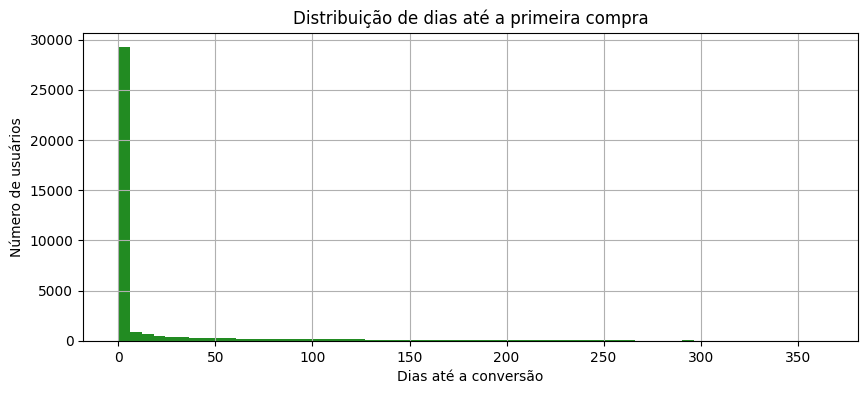

In [18]:
# Podemos utilizar um histograma para visualizar o comportamento de primeira compra dos usuários
visit_and_order['days_to_conversion'].hist(bins=60, figsize=(10, 4), color='forestgreen')
plt.title('Distribuição de dias até a primeira compra')
plt.xlabel('Dias até a conversão')
plt.ylabel('Número de usuários')
plt.show()

Nossa variável conversion_distribution mostra claramente que a grande maioria dos usuários realizam sua primeira compra logo no seu primeiro acesso, enquanto o histograma acima reforça essa afirmação. Existem sim usuários que não realizam suas compras no primeiro dia, mas eles são mínimos em comparação a quantidade de usuários que compram logo no dia zero (mesmo dia do primeiro acesso).

### Quantos pedidos os clientes fazem durante determinado período de tempo?

Encontraremos essa resposta utilizando uma abordagem mais complexa: com uma análise de coorte. Ela nos dirá quantos pedidos os usuários de cada coorte fazem ao longo do tempo, dessa forma teremos uma visão mais detalhada do comportamento de compra dos usuários.

In [19]:
# Para começar, extraímos o mês em que a compra é feita
orders['order_month'] = orders['buy_ts'].astype('datetime64[M]')

# Em seguida, extraímos o mês em que a primeira compra é feita
first_order_month = orders.groupby('uid').agg({'order_month': 'min'}).reset_index()
first_order_month.columns = ['uid', 'first_order_month']

# Adicionamos a coluna first_order_month ao DataFrame 'orders'
orders = pd.merge(orders, first_order_month, on='uid')

# Tamanho da coorte
cohort_sizes = first_order_month.groupby('first_order_month').agg({'uid': 'nunique'}).reset_index()
cohort_sizes.columns = ['first_order_month', 'n_buyers']

# Total de pedidos da coorte
cohorts = orders.groupby(['first_order_month', 'order_month']).agg({'uid': 'count'}).reset_index()
cohorts.columns = ['first_order_month', 'order_month', 'n_orders']

# Unimos as variáveis cohort_sizes e cohort para criarmos nosso relatório de pedidos por tempo
report = pd.merge(cohort_sizes, cohorts, on='first_order_month')

# Calculamos a idade de nossa coorte 
report['age'] = (report['order_month'] - report['first_order_month']) / np.timedelta64(1, 'M')
report['age'] = report['age'].round().astype('int')

# Vamos usar a média de pedidos por cliente
report['orders_per_buyer'] = report['n_orders'] / report['n_buyers']

In [20]:
# Por fim, estruturamos nossa tabela
result = report.pivot_table(
    index='first_order_month',
    columns='age',
    values='orders_per_buyer',
    aggfunc='sum'
).round(2)
result = result.fillna('')

result

age,0,1,2,3,4,5,6,7,8,9,10,11
first_order_month,,,,,,,,,,,,
2017-06-01,1.16,0.09,0.09,0.11,0.14,0.11,0.14,0.09,0.1,0.08,0.05,0.04
2017-07-01,1.14,0.05,0.06,0.05,0.04,0.04,0.03,0.03,0.03,0.01,0.03,
2017-08-01,1.12,0.08,0.07,0.06,0.06,0.05,0.04,0.06,0.03,0.03,,
2017-09-01,1.14,0.08,0.06,0.06,0.03,0.04,0.04,0.02,0.02,,,
2017-10-01,1.14,0.07,0.04,0.03,0.03,0.02,0.02,0.03,,,,
2017-11-01,1.18,0.1,0.04,0.05,0.03,0.01,0.02,,,,,
2017-12-01,1.15,0.06,0.05,0.04,0.02,0.02,,,,,,
2018-01-01,1.12,0.07,0.05,0.02,0.02,,,,,,,
2018-02-01,1.12,0.06,0.02,0.02,,,,,,,,


A análise de coorte que realizamos acima reforça o comportamento do nosso usuário. Vemos que no **primeiro mês** de cada coorte, os usuários realizam praticamente apenas **1** pedido. Nos meses seguintes praticamente não temos mais pedidos, reforçando o comportamento de uma única visita por usuário.

### Qual é o volume médio de uma compra?

Podemos dizer que o volume médio de uma compra é o ticket médio. Iremos encontrar esse valor usando duas abordagens diferentes. Primeiro, vamos encontrar um valor simples e direto que representa o ticket médio de todas as compras, depois, iremos abordar essa pergunta de maneira mais complexa, através da análise de coortes.

Dessa forma, poderemos comparar o ticket de cada coorte, em qualquer mês, com o ticket médio geral.

In [21]:
# Resposta simples e direta (ticket médio geral)
avg_ticket_per_order = orders['revenue'].mean().round(2)
print(f'ticket médio geral: {avg_ticket_per_order}')

ticket médio geral: 5.0


In [22]:
# Análise de coorte para o volume médio de uma compra (abordagem aprofundada)
cohorts_ticket = orders.groupby(['first_order_month', 'order_month']).agg({'revenue': 'mean'}).reset_index()
cohorts_ticket.columns = ['first_order_month', 'order_month', 'avg_ticket']

# Calculando a idade da coorte
cohorts_ticket['age'] = (cohorts_ticket['order_month'] - cohorts_ticket['first_order_month']) / np.timedelta64(1, 'M')
cohorts_ticket['age'] = cohorts_ticket['age'].round().astype('int')

In [23]:
# Colocamos nosso resultado em uma tabela dinâmica para observar o comportamento das diferentes coortes ao longo do tempo
ticket_result = cohorts_ticket.pivot_table(
    index='first_order_month',
    columns='age',
    values='avg_ticket',
    aggfunc='mean'
).round(2)

ticket_result = ticket_result.fillna('')

ticket_result

age,0,1,2,3,4,5,6,7,8,9,10,11
first_order_month,,,,,,,,,,,,
2017-06-01,4.06,5.55,5.09,8.55,7.08,6.83,6.97,6.76,5.28,8.01,12.04,6.04
2017-07-01,5.29,6.45,9.99,6.64,4.72,3.66,3.79,5.45,5.35,11.79,5.65,
2017-08-01,4.72,5.99,6.28,6.62,7.96,6.27,5.89,7.11,8.7,5.6,,
2017-09-01,4.97,13.17,8.35,62.57,15.43,15.32,16.77,11.21,7.79,,,
2017-10-01,4.37,7.41,5.13,5.59,5.1,5.07,4.28,4.01,,,,
2017-11-01,4.37,4.1,4.47,6.28,4.44,3.73,4.6,,,,,
2017-12-01,4.11,4.23,20.07,26.08,15.95,14.11,,,,,,
2018-01-01,3.69,4.44,6.45,7.52,2.71,,,,,,,
2018-02-01,3.71,4.58,3.45,3.87,,,,,,,,


O ticket médio para o mês zero das coortes é estável e gira em torno de valores próximos ao ticket médio geral. Nos meses seguintes, as médias frequentemente sobem, indicando que os poucos usuários que continuam comprando fazem pedidos costumam fazer pedidos mais volumosos em comparação ao pedido no mês zero.

Uma coorte que chama nossa atenção é a de setembro de 2017 (2017-09-01), o ticket médio após o mês zero sobe consideravelmente, tendo um salto absurdo de $62,57 no mês 3. Muito provavelmente, um único usuário fez um pedido muito volumoso e puxou a média do ticket para cima nesse mês. Independentemente, é fato que essa coorte teve um destaque em relação as outras em termos de volume médio da compra.

A retenção dos usuários é baixa, mas existe um nicho de "heavy users" que continuam gerando valor a longo prazo.

### Quanto dinheiro eles trazem para a empresa (LTV)?

Nosso cálculo de LTV será feito por meio de análise de coortes. Em nossa análise, teremos o LTV médio acumulado ao longo da vida da coorte.

In [24]:
# Calculamos o faturamento total
cohorts_ltv = orders.groupby(['first_order_month', 'order_month']).agg({'revenue': 'sum'}).reset_index()

# Juntamos cohorts_ltv com a variável cohort_sizes que criamos anteriormente
report_ltv = pd.merge(cohort_sizes, cohorts_ltv, on='first_order_month')

# Criamos uma coluna para o cálculo do LTV
report_ltv['ltv'] = report_ltv['revenue'] / report_ltv['n_buyers']

# Idade da coorte
report_ltv['age'] = (report_ltv['order_month'] - report_ltv['first_order_month']) / np.timedelta64(1, 'M')
report_ltv['age'] = report_ltv['age'].round().astype('int')

In [25]:
# Criamos nossa tabela contendo a coorte para o LTV
ltv_result = report_ltv.pivot_table(
    index='first_order_month',
    columns='age',
    values='ltv',
    aggfunc='mean'
).cumsum(axis=1).round(2)

ltv_result = ltv_result.fillna('')

ltv_result

age,0,1,2,3,4,5,6,7,8,9,10,11
first_order_month,,,,,,,,,,,,
2017-06-01,4.72,5.21,5.65,6.6,7.62,8.36,9.31,9.89,10.45,11.05,11.62,11.88
2017-07-01,6.01,6.35,6.97,7.33,7.5,7.66,7.78,7.92,8.08,8.23,8.39,
2017-08-01,5.28,5.75,6.21,6.6,7.09,7.38,7.59,7.99,8.28,8.47,,
2017-09-01,5.64,6.76,7.28,11.26,11.66,12.31,13.01,13.25,13.44,,,
2017-10-01,5.00,5.54,5.73,5.89,6.04,6.16,6.24,6.36,,,,
2017-11-01,5.15,5.55,5.75,6.08,6.23,6.28,6.4,,,,,
2017-12-01,4.74,5.0,5.92,6.99,7.3,7.64,,,,,,
2018-01-01,4.14,4.43,4.73,4.88,4.94,,,,,,,
2018-02-01,4.16,4.44,4.51,4.59,,,,,,,,


Como sabemos, a maioria dos clientes não voltam, como resultado, o LTV cresce de forma lenta mês a mês. Para a primeira coorte, o LTV logo no mês zero foi de 4,72. Depois de quase um ano, o valor atingiu 11,88, ou seja, a Y.Fisha leva um ano para extrair um pouco mais do dobro do valor inicial daquela base de clientes.

A coorte 2017-09-01, a mesma que chamou atenção devido aos pedidos volumosos, possui valores atípicos de LTV. Devido aos pedidos mais volumosos feitos pelos usuários dessa coorte, o LTV de toda a coorte subiu consideravelmente.

## Etapa 2.3. Marketing

### Quanto dinheiro foi gasto? No total / por origem / ao longo do tempo

Agora, o foco será analisar os gastos com marketing pela Y.Afisha. Para começar, vamos verificar apenas o quanto foi gasto com marketing ao longo do período de nossa análise, depois iremos calcular os gastos por origem (fonte de tráfego) e por fim, vamos calcular o gasto ao longo do tempo.

In [26]:
# Gastos no total
# Criamos a variável total_costs para conter o gasto total com marketing 
total_costs = costs['costs'].sum()
print(f'Gasto total: ${total_costs}')

Gasto total: $329131.62


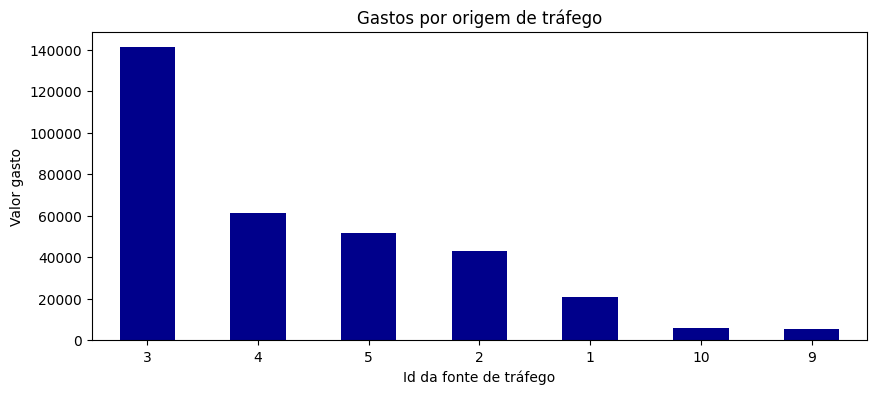

In [27]:
# Gastos por origem
# Criamos uma variável contendo os gastos agrupados por origem
source_costs = costs.groupby('source_id').agg({'costs': 'sum'}).sort_values(by='costs', ascending=False)

# Criamos um gráfico para visualizar os gastos por origem
source_costs.plot(
    kind='bar',
    title='Gastos por origem de tráfego',
    ylabel='Valor gasto',
    xlabel='Id da fonte de tráfego',
    rot=0,
    figsize=(10, 4),
    legend=False,
    color='darkblue'
)

plt.show()

Esse gráfico nos mostra que a Y.Fisha investiu muito na **fonte de tráfego 3**. O valor investido nela foi mais do que o dobro do que a segunda fonte mais investida (fonte 4). Enquanto nas fontes 9 e 10, os investimentos foram baixíssimos. 

Porém, não é um problema investir mais, ou menos em uma fonte. O que importa, é que o investimento feito gere retorno para a empresa. Por isso, iremos ficar atentos ao ROI, principalmente para a fonte de tráfego 3, já que ela foi a maior aposta da empresa.

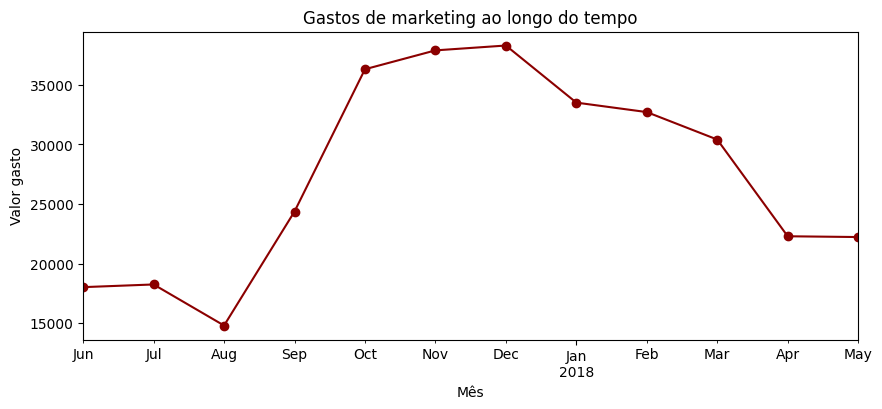

In [28]:
# Gastos ao longo do tempo
# Para conseguir encontrar os gastos ao longo do tempo (meses), 
# Precisamos criar uma coluna contendo o mês do gasto em nossa tabela de custos com marketing (costs)
costs['cost_month'] = costs['dt'].astype('datetime64[M]')

# Criamos uma variável que contém os gastos somados ao longo dos meses
costs_over_time = costs.groupby('cost_month').agg({'costs': 'sum'}).reset_index()

# Plotamos um gráfico de linhas da nossa variável
costs_over_time.plot(
    kind='line',
    title='Gastos de marketing ao longo do tempo',
    x='cost_month',
    y='costs',
    ylabel='Valor gasto',
    xlabel='Mês',
    figsize=(10, 4),
    color='darkred',
    legend=False,
    marker='o'
)

plt.show()

Os gastos com marketing estavam relativamente baixos até agosto de 2017, mas já em setembro, os gastos aumentaram muito, atingindo um ápice em dezembro de 2017, apontando para campanhas agressivas de final de ano.

Podemos ver uma relação de causa e efeito entre os investimentos em marketing e o tamanho do ticket médio. No mesmo mês em que os investimentos em marketing aumentaram, o ticket médio da coorte de setembro de 2017 também aumentou. Ou seja, as campanhas desse período foram muito focadas nos usuários dessa coorte. Aliás, o ticket médio absurdo de $62,57 atingido por essa coorte, foi no mesmo mês em que a Y.Afisha fez o investimento mais pesado em marketing (dezembro).

### Quanto custou a aquisição de clientes para cada origem?

Para responder a essa pergunta, iremos estrutrar nossa resposta em partes, visando facilitar a compreensão geral do raciocínio apresentado.

#### Parte 1
O primeiro passo para responder a essa pergunta é descobrir qual foi a origem de tráfego de cada usuário, para isso, precisamos das seguintes informações:
- Data do primeiro login
- Fonte de tráfego do primeiro login

Nós já temos uma variável que contêm a data do primeiro login dos usuários (first_visit), porém, ela não possui a coluna 'source_id' (fonte do tráfego). Para obtermos essa informação iremos cruzar nossa variável first_visits com a tabela visits utilizando uma chave composta (uid + data do primeiro login). 

Assim, o resultado será uma tabela contendo apenas uma linha para cada usuário, monstrando apenas os dados da primeira visita. Dessa forma, conseguimos mapear de qual fonte de tráfego cada usuário veio.

In [29]:
# Realizamos a intersecção da tabela de visitas com a série contendo as primeiras visitas
first_visit_source = pd.merge(
    first_visit,
    visits,
    left_on=['uid', 'first_visit_date'], 
    right_on=['uid', 'start_ts']  # Usamos uma chave composta para obtermos apenas a primeira visita de cada usuário
)

# A coluna device não será usada para calcular o CAC, mas para pordermos calcular o LTV por origem e
# dispositivo, iremos precisar da coluna device
first_visit_source = first_visit_source[['uid', 'source_id', 'device']]

# Visualizando a variável criada
first_visit_source

,uid,source_id,device
0,11863502262781,3,touch
1,49537067089222,2,touch
2,297729379853735,3,desktop
3,313578113262317,2,desktop
4,325320750514679,5,desktop
...,...,...,...
228165,18446403737806311543,5,desktop
228166,18446424184725333426,4,touch
228167,18446556406699109058,3,touch
228168,18446621818809592527,4,desktop


### Parte 2

Nós mapeamos a fonte de tráfego de cada usuário, mas nossa série first_visit_source não nos diz quais desses clientes realmente realizaram uma compra, mas para calcular o CAC (custo de aquisição de **clientes**) nós precisamos saber quais usuários foram convertidos a clientes por meio da compra na plataforma da Y.Afisha. 

Para descobrir os usuários que, de fato, se tornaram clientes, vamos isolar os usuários únicos da tabela orders, assim saberemos quais foram os usuários que de fato realizaram uma compra. Feito isso, poderemos agrupar essa tabela pelo primeiro mês da compra e a fonte de tráfego, depois somamos os usuários únicos. O nosso resultado será uma tabela contendo a data do primeiro pedido, para cada fonte e o número de compradores para cada fonte e mês.

In [30]:
# Encontramos os compradores por origem juntando nossa tabela orders com a tabela first_visit_source
buyers = pd.merge(orders, first_visit_source, on='uid')

# Agrupamento a tabela buyers para encontrar os clientes únicos por mês e origem
cohort_buyers_cac = buyers.groupby(['first_order_month', 'source_id']).agg({'uid': 'nunique'}).reset_index()
cohort_buyers_cac.rename(columns={'uid': 'n_buyers_total'}, inplace=True)

# Visualizando a tabela
cohort_buyers_cac

,first_order_month,source_id,n_buyers_total
0,2017-06-01,1,190
1,2017-06-01,2,235
2,2017-06-01,3,638
3,2017-06-01,4,413
4,2017-06-01,5,384
...,...,...,...
81,2018-05-01,4,804
82,2018-05-01,5,497
83,2018-05-01,9,60
84,2018-05-01,10,130


### Parte 3

Depois de montarmos nossa tabela contendo a data do primeiro pedido, a fonte de tráfego e o número de compradores, precisamos montar uma tabela contendo os custos por mês, fonte de tráfego e o quanto foi gasto com cada fonte em cada mês. Feito isso, poderemos unir as duas tabelas criadas. Ela irá conter as informações necessárias para calcular o **CAC** ao longo do **tempo** por **origem**.

Por fim, iremos criar uma tabela dinâmica com nossos dados, para que possamos criar um gráfico de linhas adequado para visualizar o CAC.

In [31]:
# Calculando custos por coorte e origem
cohort_costs = costs.groupby(['cost_month', 'source_id']).agg({'costs': 'sum'}).reset_index()
cohort_costs.rename(columns={'costs': 'source_costs'}, inplace=True)

# Visualizando a tabela criada
cohort_costs

,cost_month,source_id,source_costs
0,2017-06-01,1,1125.61
1,2017-06-01,2,2427.38
2,2017-06-01,3,7731.65
3,2017-06-01,4,3514.80
4,2017-06-01,5,2616.12
...,...,...,...
79,2018-05-01,3,9411.42
80,2018-05-01,4,4214.21
81,2018-05-01,5,3669.56
82,2018-05-01,9,362.17


In [32]:
# Juntamos cohort_buyers e cohort_costs para calcular o CAC
report_cac = pd.merge(
    cohort_buyers_cac,
    cohort_costs,
    left_on=['first_order_month', 'source_id'],
    right_on=['cost_month', 'source_id']
)

# Criamos uma coluna contendo o CAC para cada usuário 
report_cac['cac'] = (report_cac['source_costs'] / report_cac['n_buyers_total']).round(2)

# Visualizando nossa tabela
report_cac.head(7)

,first_order_month,source_id,n_buyers_total,cost_month,source_costs,cac
0,2017-06-01,1,190,2017-06-01,1125.61,5.92
1,2017-06-01,2,235,2017-06-01,2427.38,10.33
2,2017-06-01,3,638,2017-06-01,7731.65,12.12
3,2017-06-01,4,413,2017-06-01,3514.80,8.51
4,2017-06-01,5,384,2017-06-01,2616.12,6.81
5,2017-06-01,9,68,2017-06-01,285.22,4.19
6,2017-06-01,10,95,2017-06-01,314.22,3.31


Rapidamente, nessa tabela temos o CAC por origem para a coorte 2017-06-01. Porém, para conseguirmos visualizar adequadamente o CAC ao longo do tempo e por origem, não incluiremos as coortes. Nosso resultado será um gráfico de linhas para cada gasto.

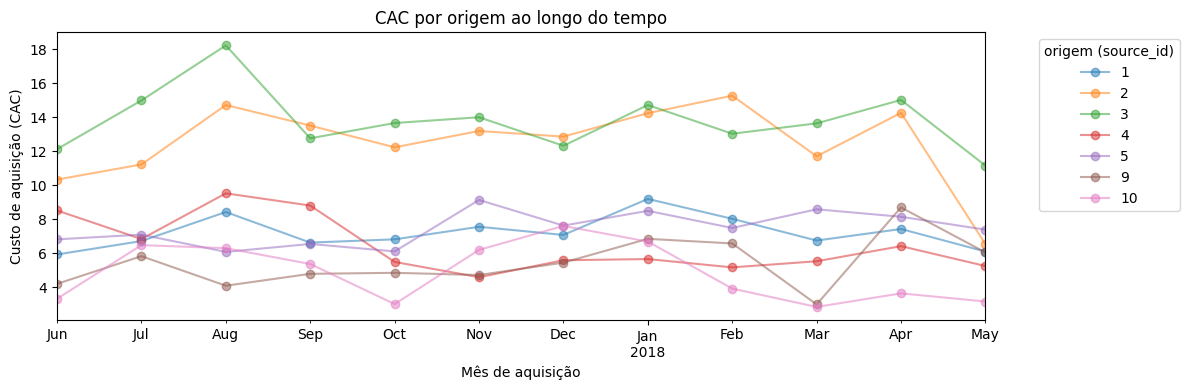

In [33]:
# Rearranjamos a tabela com pivot_table para criarmos um gráfico 
cac_pivot = report_cac.pivot_table(
    index='cost_month',
    columns='source_id',
    values='cac'
)

# Plotamos um gráfico para visualizar os resultados 
cac_pivot.plot(
    kind='line',
    title='CAC por origem ao longo do tempo',
    xlabel='Mês de aquisição',
    ylabel='Custo de aquisição (CAC)',
    marker='o',
    figsize=(12, 4),
    alpha=0.5
)

plt.legend(title='origem (source_id)', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Logo de cara vemos que os canais 2 e 3 são fontes de tráfego caras. O CAC delas ao longo do tempo é consideralvemente superior aos das outras fontes. No canal 3, o CAC chega a superar $18.

As fontes 1 e 5 são as mais previsíveis e se encontram no meio termo em comparação às outras. O CAC dessas duas se mantêm na faixa de $(6 ~ 9).

As fontes 9 e 10, no geral, são as mais baratas, com custo de aquisição ficando abaixo de $4 em alguns meses.

Porém, para que possamos definir se os investimentos nas origens valeram a pena, precisamos calcular o ROI de cada uma.

### Os investimentos valeram a pena? (ROI)

O cálculo do ROI será feito para cada origem e dispositivo, assim, poderemos responder quais fontes de tráfego são mais recomendáveis para investimentos futuros e em quais dispositivos focar. Para esse cálculo, não poderemos usar o LTV que calculamos anteriormente, pois ele não está separado por origem. 

### Passo 1:
Calcular o LTV por fonte de tráfego e dispositivo, para isso, usaremos nossa tabela buyers criada anteriormente (contém os dados de compra e origem do tráfego). Essa tabela possui as informações da receita, id do usuário, mês do pedido, mês do primeiro pedido, fonte do tráfego e o dispositivo usado (tudo o que precisamos). A partir dessa tabela buyers iremos criar outras duas tabelas:
- **cohort_buyers_ltv**: irá conter os usuários agrupados por mês do primeiro pedido, source id (fonte de tráfego) e dispositivo
- **revenue_by_source**: irá conter a receita somada e agrupada por mês do primeiro pedido, source id e dispositivo (da mesma forma que cohort_buyers_ltv).

Feitas essas duas tabelas, vamos úni-las na tabela **report_ltv_source**, que irá conter as informações necessárias alinhadas para calcularmos o LTV.

### Passo 2:
Iremos unir a a tabela report_ltv_source com a tabela report_cac criada para calcular o cac dos usuários. A tabela resultando será chamada **report_roi**, usaremos ela para calcular o ROI.

### Observação:
É importante ressaltar que o custo por clicks no computador e acessos em dispositivos móveis possuem valores diferentes, logo o custo associado a cada tipo de dispositivo deveria ser diferente, porém, os dados disponíveis para esse projeto não nos permite calcular o CAC para cada dispositivo. Por isso, usaremos o CAC geral encontrado na etapa anterior. Não é o ideal, mas nos ajudará a identificar qual(is) fonte(s) de tráfego e dispositivo(s) tiveram um melhor desempenho.

### Passo 1

In [34]:
# Precisamos agrupar novamente a tabela buyers para encontrar os clientes únicos por mês, origem e dispositivo
cohort_buyers_ltv = buyers.groupby(['first_order_month', 'source_id', 'device'], observed=True).agg({'uid': 'nunique'}).reset_index()
cohort_buyers_ltv.rename(columns={'uid': 'n_buyers'}, inplace=True)

In [35]:
# Calculamos o faturamento agrupando por coorte, origem e mês do pedido
revenue_by_source = buyers.groupby(['first_order_month', 'source_id', 'order_month', 'device'], observed=True).agg({'revenue': 'sum'}).reset_index()

# Visualizando a tabela criada
revenue_by_source

,first_order_month,source_id,order_month,device,revenue
0,2017-06-01,1,2017-06-01,desktop,1249.17
1,2017-06-01,1,2017-06-01,touch,129.53
2,2017-06-01,1,2017-07-01,desktop,413.15
3,2017-06-01,1,2017-07-01,touch,1.83
4,2017-06-01,1,2017-08-01,desktop,419.43
...,...,...,...,...,...
879,2018-05-01,9,2018-05-01,desktop,188.36
880,2018-05-01,9,2018-05-01,touch,34.69
881,2018-05-01,10,2018-05-01,desktop,373.58
882,2018-05-01,10,2018-05-01,touch,97.31


In [36]:
# Juntamos revenue_by_source com cohort_buyers usando uma chave composta
report_ltv_source = pd.merge(cohort_buyers_ltv, revenue_by_source, on=['first_order_month', 'source_id', 'device'])

# Visualizando a tabela criada
print(report_ltv_source)

    first_order_month  source_id   device  n_buyers order_month  revenue
0          2017-06-01          1  desktop       163  2017-06-01  1249.17
1          2017-06-01          1  desktop       163  2017-07-01   413.15
2          2017-06-01          1  desktop       163  2017-08-01   419.43
3          2017-06-01          1  desktop       163  2017-09-01   692.92
4          2017-06-01          1  desktop       163  2017-10-01   768.36
..                ...        ...      ...       ...         ...      ...
879        2018-05-01          9  desktop        49  2018-05-01   188.36
880        2018-05-01          9    touch        11  2018-05-01    34.69
881        2018-05-01         10  desktop        95  2018-05-01   373.58
882        2018-05-01         10    touch        35  2018-05-01    97.31
883        2018-06-01          4  desktop         1  2018-06-01     3.42

[884 rows x 6 columns]


In [37]:
# Agora criamos uma coluna para calcular o LTV por origem
report_ltv_source['ltv_source'] = report_ltv_source['revenue']/ report_ltv_source['n_buyers']

# Calculamos a idade da coorte
report_ltv_source['age'] = (report_ltv_source['order_month'] - report_ltv_source['first_order_month']) / np.timedelta64(1, 'M')
report_ltv_source['age'] = report_ltv_source['age'].round().astype('int')

# Visualizando as colunas criadas
report_ltv_source

,first_order_month,source_id,device,n_buyers,order_month,revenue,ltv_source,age
0,2017-06-01,1,desktop,163,2017-06-01,1249.17,7.663620,0
1,2017-06-01,1,desktop,163,2017-07-01,413.15,2.534663,1
2,2017-06-01,1,desktop,163,2017-08-01,419.43,2.573190,2
3,2017-06-01,1,desktop,163,2017-09-01,692.92,4.251043,3
4,2017-06-01,1,desktop,163,2017-10-01,768.36,4.713865,4
...,...,...,...,...,...,...,...,...
879,2018-05-01,9,desktop,49,2018-05-01,188.36,3.844082,0
880,2018-05-01,9,touch,11,2018-05-01,34.69,3.153636,0
881,2018-05-01,10,desktop,95,2018-05-01,373.58,3.932421,0
882,2018-05-01,10,touch,35,2018-05-01,97.31,2.780286,0


### Passo 2

In [38]:
# Agora que temos uma tabela contendo o LTV por origem e outra contendo o CAC por origem, vamos juntá-las para podermos calcular o ROI

report_roi = pd.merge(
    report_ltv_source,
    report_cac[['first_order_month', 'source_id', 'cac']],
    on=['first_order_month', 'source_id']
)

# Calculamos o ROI
report_roi['roi'] = (report_roi['ltv_source'] / report_roi['cac']).round(2)


report_roi

,first_order_month,source_id,device,n_buyers,order_month,revenue,ltv_source,age,cac,roi
0,2017-06-01,1,desktop,163,2017-06-01,1249.17,7.663620,0,5.92,1.29
1,2017-06-01,1,desktop,163,2017-07-01,413.15,2.534663,1,5.92,0.43
2,2017-06-01,1,desktop,163,2017-08-01,419.43,2.573190,2,5.92,0.43
3,2017-06-01,1,desktop,163,2017-09-01,692.92,4.251043,3,5.92,0.72
4,2017-06-01,1,desktop,163,2017-10-01,768.36,4.713865,4,5.92,0.80
...,...,...,...,...,...,...,...,...,...,...
877,2018-05-01,5,touch,93,2018-05-01,359.02,3.860430,0,7.38,0.52
878,2018-05-01,9,desktop,49,2018-05-01,188.36,3.844082,0,6.04,0.64
879,2018-05-01,9,touch,11,2018-05-01,34.69,3.153636,0,6.04,0.52
880,2018-05-01,10,desktop,95,2018-05-01,373.58,3.932421,0,3.15,1.25


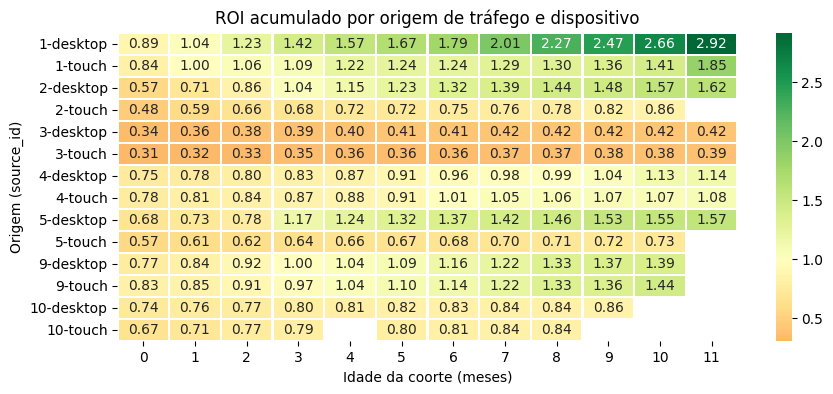

In [39]:
# Calculado o ROI, criaremos uma tabela dinâmica
roi_pivot = report_roi.pivot_table(
    index=['source_id', 'device'],
    columns='age',
    values='roi',
    aggfunc='mean'
).cumsum(axis=1).round(2)

# Mapa de calor do cálculo do ROI por origem
plt.figure(figsize=(10, 4))
plt.title('ROI acumulado por origem de tráfego e dispositivo')
sns.heatmap(
    roi_pivot,
    annot=True,
    fmt='.2f',
    linewidths=1,
    cmap='RdYlGn',
    center=1
)
plt.ylabel('Origem (source_id)')
plt.xlabel('Idade da coorte (meses)')
plt.show()

O mapa de calor do ROI dividido por fontes e dispostivos nos permite identificar quais investimentos foram melhores. Primeiramente, olhando para a fonte 3, vemos que em um ano ela não foi capaz de se pagar, tanto para os usuários de desktop, quanto de dispositivos móveis. A realidade, é que a fonte não abateu nem metade dos valores investidos, representando um cenário extremamente preocupante, pois foi a fonte de maior investimento da Y.Afisha (aproximadamente **$140.000,00**). Além da fonte 3, a 10 também não se pagou. O investimento nela foi baixo em relação às outras, mas não deixa de representar perdas.

Todas as outras fontes se pagaram em algum momento, pelo menos em um dos dispositivos. O grande destaque vai para a **fonte 1**. O ROI dela atingiu 1.04 em desktops e 1.0 em dispositivos mobile após 1 mês, ou seja, os investimentos se pagaram e estavam começando a retornar lucros. Em um ano, o ROI dela em desktops atingiu **2.92**, sendo disparado o valor mais alto da tabela. Esse desempenho é muito valioso para a empresa, pois sabemos que o usuário médio da plataforma não costuma voltar depois de realizar uma compra.

As origens 2 e 5 passaram a dar lucro a partir do mês 3, mas somente para desktops. Ambas tiveram desempenho pior em dispositivos mobile.

A origem 4 não teve um desempenho significativo, o ROI dela passou de 1 apenas depois do mês 6 e somente em dispositivos móveis. Por fim, a origem 9, a fonte com menor valor investido, atingiu um ROI de 1 já no terceiro mês para desktops, no mês seguinte, passou do 1 para dispositivos móveis. A longo prazo, atingiu um ROI interessante em relação às outras fontes (exceto a origem 1).

# Etapa 3. conclusão

## Métricas analisadas

Analisamos as atividades diária, semanal e mensal dos usuários, a ASL (average session lenght) e as taxas de adesão semanal e mensal. Essas métricas foram importantes para definir o perfil e o comportamento dos usários na plataforma da Y.Afisha. Observamos que o usuário médio costuma fazer um acesso, realizar uma compra e sair, tudo em 60 segundos. Após essa primeira visita, a grande maioria dos usuários não voltam mais. Existem alguns "heavy users", mas eles são uma parcela muito pequena de usuários. A empresa depende de novos usuários chegando para realizar novos pedidos.

Para determinar se os investimentos em marketing valeram a pena, calculamos o ROI por origem de tráfego e tipo de dispositivo. Essa análise nos permitiu visualizar quais fontes de tráfego obtiveram melhor desempenho e quais são mais adequadas ao modelo de negócio da empresa. Para o cálculo do ROI, utilizamos outras duas métricas: LTV (lifetime value) e CAC (client aquisition cost). 

Calculamos o LTV de forma geral, separado apenas por coortes (divididas por mês) ao longo do ano. Dessa forma, obtemos uma visão macro do LTV do usuário ao longo do período analisado. Também calculamos o LTV segmentado por origem de tráfego e dispositivos, pois essa métrica é fundamental para calcular o ROI dividido também por diferentes origens e dispositivos. O CAC foi calculado de forma geral e separado por coortes (divididas por mês).

Através do ROI descobrimos quais fontes de tráfego valiam a pena continuar investindo e quais parar / diminuir os investimentos, além de identificarmos em quais dispositivos investir dependendo da fonte de tráfego.

## Em quais origens e plataformas investir

**Paralisação imediata**: os investimentos na origem 3 devem ser cortados de imediato. Foi a origem com maior investimento e o ROI dela após um ano não atingiu o valor de 0.5 (para ambas as plataformas).

**Foco de reinvestimento**: a origem 1 definitivamente foi a melhor de todas e deve ser o foco de investimentos. O ROI dela, para ambos os dispositivos, atingiu o valor de 1 após o  primeiro mês, o que é muito valioso para a Y.Afisha, pois seus usuários possuem uma baixa adesão, além disso, ROI dela foi o que mais cresceu em um ano. As origens 2 e 5 também devem receber mais investimentos, mas somente para dispositivos desktop. Caso seja do interesse da diretoria investir uma parcela em dispositivos móveis, o foco deve ser nas origens 1 e 9.

**Foco em dispositivos**: As campanhas de marketing devem ser segmentadas para priorizar majoritariamente o tráfego em dispositivos desktop. 